# KGAS Cusp vs Core Kinematic Fitting

Compare pseudo-isothermal (core) and NFW (cusp) dark matter velocity profiles
for KGAS using visibility-space fitting with **UVfit** + **KinMS**.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import os

from uvfit import UVDataset, Fitter
from uvfit.forward_model import KinMSModel
from astropy.io import fits as pyfits
from pymakeplots import pymakeplots as pmp

try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("Install 'corner' for corner plots: pip install corner")

## 2. Configuration

In [2]:
# ── Paths (edit for local vs CANFAR) ──
DATA_PATH = "/Users/thbrown/kilogas/DR1/visibilities/KILOGAS007.small.npz"

# ── Source parameters ──
VSYS = 13583.0        # systemic velocity, km/s
VMAX = 200.0          # maximum rotation velocity, km/s
R_SCALE = 3.0         # scale radius, arcsec
PA_INIT = 147.4       # position angle, degrees
CELLSIZE = 0.1        # arcsec per pixel

# ── CO(2-1) rest frequency ──
F_REST = 230.538e9    # Hz
C_KMS = 299792.458    # speed of light, km/s

# ── Cube geometry ──
NX = NY = 256         # spatial pixels (FOV = 256 * 0.1 = 51.2 arcsec)
VEL_BUFFER = 100.0    # km/s buffer beyond ±Vmax for trimming

## 3. Load and inspect data

In [3]:
d = np.load(DATA_PATH)
u_all, v_all = d["u"], d["v"]
vis_all, weights_all = d["vis"], d["weights"]
freqs_all = d["freqs"]

print(f"Baselines : {u_all.shape[0]}")
print(f"Channels  : {freqs_all.shape[0]}")
print(f"Freq range: {freqs_all.min()/1e9:.4f} – {freqs_all.max()/1e9:.4f} GHz")

Baselines : 2228
Channels  : 960
Freq range: 219.0665 – 220.9395 GHz


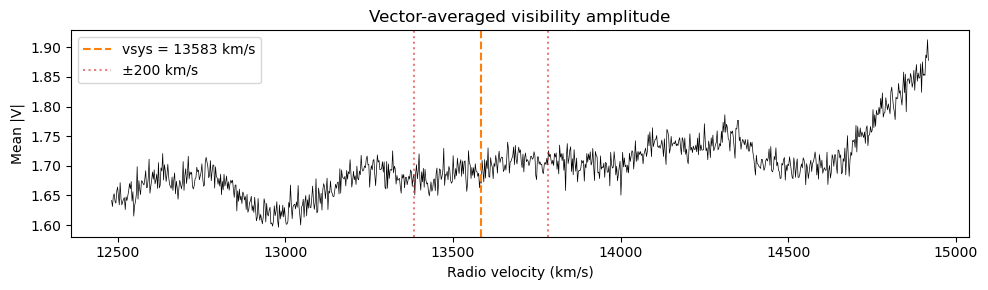

In [4]:
avg_amp = np.abs(vis_all).mean(axis=0)
vel_all = C_KMS * (1.0 - freqs_all / F_REST)

fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(vel_all, avg_amp, "k-", lw=0.5)
ax1.axvline(VSYS, color="C1", ls="--", label=f"vsys = {VSYS:.0f} km/s")
ax1.axvline(VSYS - VMAX, color="C3", ls=":", alpha=0.6)
ax1.axvline(VSYS + VMAX, color="C3", ls=":", alpha=0.6,
            label=f"±{VMAX:.0f} km/s")
ax1.set_xlabel("Radio velocity (km/s)")
ax1.set_ylabel("Mean |V|")
ax1.set_title("Vector-averaged visibility amplitude")
ax1.legend()
plt.tight_layout()
plt.show()

## 4. Trim to line channels

In [5]:
v_lo = VSYS - VMAX - VEL_BUFFER
v_hi = VSYS + VMAX + VEL_BUFFER

chan_mask = (vel_all >= v_lo) & (vel_all <= v_hi)
print(f"Keeping {chan_mask.sum()} of {len(vel_all)} channels "
      f"({v_lo:.0f} – {v_hi:.0f} km/s)")

freqs_trim = freqs_all[chan_mask]
vis_trim = vis_all[:, chan_mask]
weights_trim = weights_all[:, chan_mask]
vel_trim = vel_all[chan_mask]

# Channel width in km/s (use median of absolute differences)
dv_kms = float(np.median(np.abs(np.diff(vel_trim))))
n_chan_trim = int(chan_mask.sum())
print(f"Channel width: {dv_kms:.3f} km/s")
print(f"Velocity range: {vel_trim.min():.1f} – {vel_trim.max():.1f} km/s")
print(f"Trimmed cube will have {n_chan_trim} channels")

uvdata = UVDataset(
    u=u_all, v=v_all,
    vis_data=vis_trim, weights=weights_trim, freqs=freqs_trim,
)
print(f"UVDataset: {uvdata.n_baseline} baselines × {uvdata.n_chan} channels")

Keeping 236 of 960 channels (13283 – 13883 km/s)
Channel width: 2.540 km/s
Velocity range: 13284.5 – 13881.4 km/s
Trimmed cube will have 236 channels
UVDataset: 2228 baselines × 236 channels


## 5. Define velocity profiles

**Core** (pseudo-isothermal sphere): linear rise at small r, flat at large r.  
**Cusp** (NFW): steep r^0.5 rise at small r, peaks then gently declines.

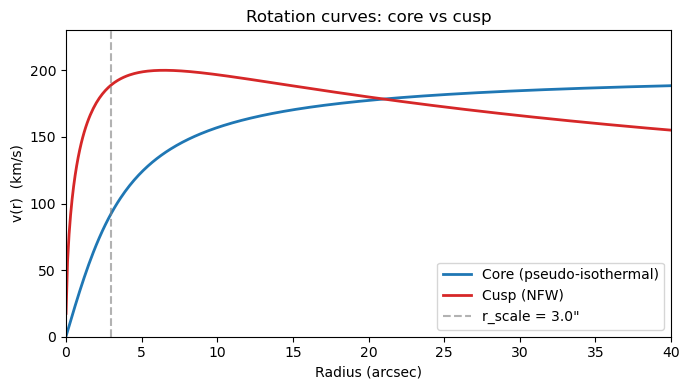

In [6]:
radius = np.arange(0.01, 100, 0.1)  # arcsec

# Surface brightness: exponential disk
sbprof = np.exp(-radius / R_SCALE)

# ── Core: pseudo-isothermal sphere ──
# v(r) = Vmax * sqrt(1 - (r_c/r) * arctan(r/r_c))
x_core = radius / R_SCALE
v_core = VMAX * np.sqrt(1.0 - np.arctan(x_core) / x_core)

# ── Cusp: NFW ──
# g(x) = ln(1+x) - x/(1+x); v(r) ∝ sqrt(g(x)/x), normalised to peak at Vmax
x_nfw = radius / R_SCALE
g_nfw = np.log(1.0 + x_nfw) - x_nfw / (1.0 + x_nfw)
g_over_x = g_nfw / x_nfw
v_cusp = VMAX * np.sqrt(g_over_x / np.max(g_over_x))

# ── Plot ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(radius, v_core, "C0-", lw=2, label="Core (pseudo-isothermal)")
ax.plot(radius, v_cusp, "C3-", lw=2, label="Cusp (NFW)")
ax.axvline(R_SCALE, color="grey", ls="--", alpha=0.6,
           label=f"r_scale = {R_SCALE}\"")
ax.set_xlabel("Radius (arcsec)")
ax.set_ylabel("v(r)  (km/s)")
ax.set_title("Rotation curves: core vs cusp")
ax.legend()
ax.set_xlim(0, 40)
ax.set_ylim(0, VMAX * 1.15)
plt.tight_layout()
plt.show()

## 6. Core model: gradient fit + MCMC

In [7]:
core_model = KinMSModel(
    xs=NX, ys=NY, vs=n_chan_trim,
    cell_size_arcsec=CELLSIZE,
    channel_width_kms=dv_kms,
    sbprof=sbprof,
    velprof=v_core,
    sbrad=radius,
    velrad=radius,
)

core_init = {
    "inc": 15.0,
    "pa": PA_INIT,
    "flux": 1.0,
    "vsys": 0.0,
    "gas_sigma": 10.0,
}

fitter_core = Fitter(uvdata=uvdata, forward_model=core_model)

print("Running gradient fit (L-BFGS-B) for CORE model...")
result_core_grad = fitter_core.fit(
    initial_params=core_init, method="L-BFGS-B",
)
print(f"Best-fit: {result_core_grad.params}")
print(f"Reduced χ²: {result_core_grad.reduced_chi2:.6f}")

Running gradient fit (L-BFGS-B) for CORE model...
Best-fit: {'inc': np.float64(15.0), 'pa': np.float64(147.4), 'flux': np.float64(2.3251205709664777), 'vsys': np.float64(0.0), 'gas_sigma': np.float64(10.0)}
Reduced χ²: 1.101079


In [8]:
print("Running MCMC (emcee) for CORE model...")
result_core = fitter_core.fit(
    initial_params=result_core_grad.params,
    method="emcee",
    n_walkers=16,
    n_steps=200,
    n_burn=50,
)
print(f"MAP params: {result_core.params}")
print(f"Reduced χ² (core): {result_core.reduced_chi2:.6f}")

Running MCMC (emcee) for CORE model...


100%|██████████| 200/200 [27:57<00:00,  8.39s/it]


MAP params: {'inc': np.float64(59.644968811306356), 'pa': np.float64(31.880878488765422), 'flux': np.float64(32.87795959220736), 'vsys': np.float64(52.59093593644215), 'gas_sigma': np.float64(37.93544518264814)}
Reduced χ² (core): 1.100939


## 7. Cusp model: gradient fit + MCMC

In [9]:
cusp_model = KinMSModel(
    xs=NX, ys=NY, vs=n_chan_trim,
    cell_size_arcsec=CELLSIZE,
    channel_width_kms=dv_kms,
    sbprof=sbprof,
    velprof=v_cusp,
    sbrad=radius,
    velrad=radius,
)

cusp_init = {
    "inc": 15.0,
    "pa": PA_INIT,
    "flux": 1.0,
    "vsys": 0.0,
    "gas_sigma": 10.0,
}

fitter_cusp = Fitter(uvdata=uvdata, forward_model=cusp_model)

print("Running gradient fit (L-BFGS-B) for CUSP model...")
result_cusp_grad = fitter_cusp.fit(
    initial_params=cusp_init, method="L-BFGS-B",
)
print(f"Best-fit: {result_cusp_grad.params}")
print(f"Reduced χ²: {result_cusp_grad.reduced_chi2:.6f}")

Running gradient fit (L-BFGS-B) for CUSP model...
Best-fit: {'inc': np.float64(15.0), 'pa': np.float64(147.4), 'flux': np.float64(6.616591561046481), 'vsys': np.float64(0.0), 'gas_sigma': np.float64(10.0)}
Reduced χ²: 1.101071


In [10]:
print("Running MCMC (emcee) for CUSP model...")
result_cusp = fitter_cusp.fit(
    initial_params=result_cusp_grad.params,
    method="emcee",
    n_walkers=16,
    n_steps=200,
    n_burn=50,
)
print(f"MAP params: {result_cusp.params}")
print(f"Reduced χ² (cusp): {result_cusp.reduced_chi2:.6f}")

Running MCMC (emcee) for CUSP model...


100%|██████████| 200/200 [28:18<00:00,  8.49s/it]


MAP params: {'inc': np.float64(19.03659331194584), 'pa': np.float64(27.70097212902847), 'flux': np.float64(52.02937127355921), 'vsys': np.float64(8.499231441898981), 'gas_sigma': np.float64(43.559768143119825)}
Reduced χ² (cusp): 1.100952


## 8. Model comparison

In [11]:
n_data = 2 * uvdata.vis_data.size  # real + imaginary components
k = 5  # number of free parameters (same for both models)

bic_core = result_core.chi2 + k * np.log(n_data)
bic_cusp = result_cusp.chi2 + k * np.log(n_data)
delta_bic = bic_cusp - bic_core

print("=" * 55)
print(f"{'Metric':<25} {'Core':>12} {'Cusp':>12}")
print("-" * 55)
print(f"{'χ²':<25} {result_core.chi2:>12.2f} {result_cusp.chi2:>12.2f}")
print(f"{'Reduced χ²':<25} {result_core.reduced_chi2:>12.6f} {result_cusp.reduced_chi2:>12.6f}")
print(f"{'BIC':<25} {bic_core:>12.2f} {bic_cusp:>12.2f}")
print("-" * 55)
print(f"{'ΔBIC (cusp − core)':<25} {delta_bic:>12.2f}")
print("=" * 55)

if delta_bic > 6:
    print("Strong evidence for CORE over cusp.")
elif delta_bic < -6:
    print("Strong evidence for CUSP over core.")
else:
    print("No strong preference (|ΔBIC| < 6).")

Metric                            Core         Cusp
-------------------------------------------------------
χ²                          1157759.92   1157772.93
Reduced χ²                    1.100939     1.100952
BIC                         1157829.25   1157842.26
-------------------------------------------------------
ΔBIC (cusp − core)               13.01
Strong evidence for CORE over cusp.


### Corner plots

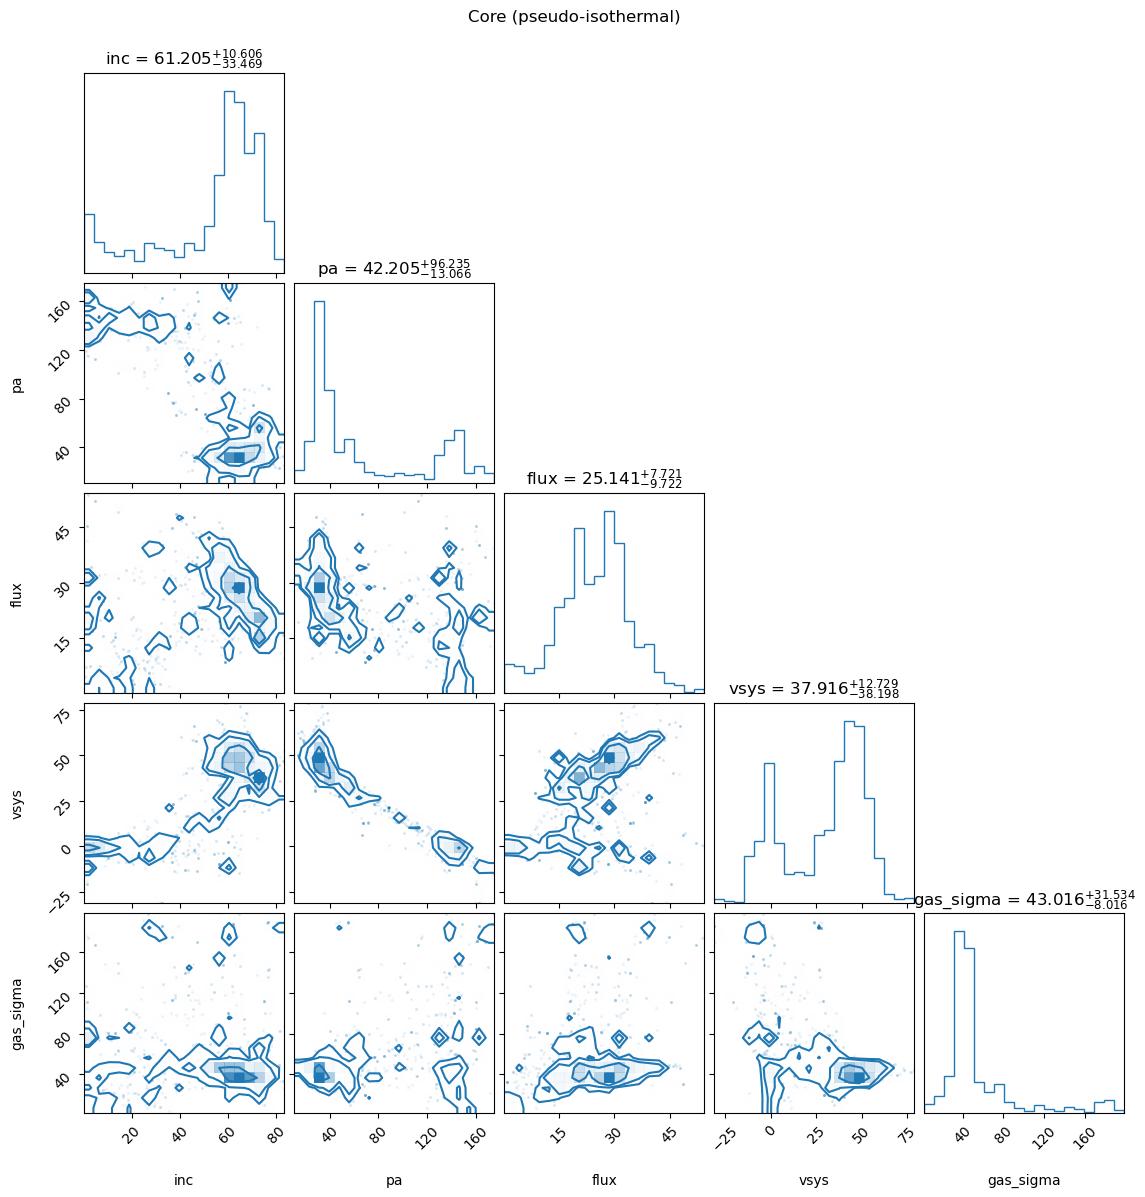

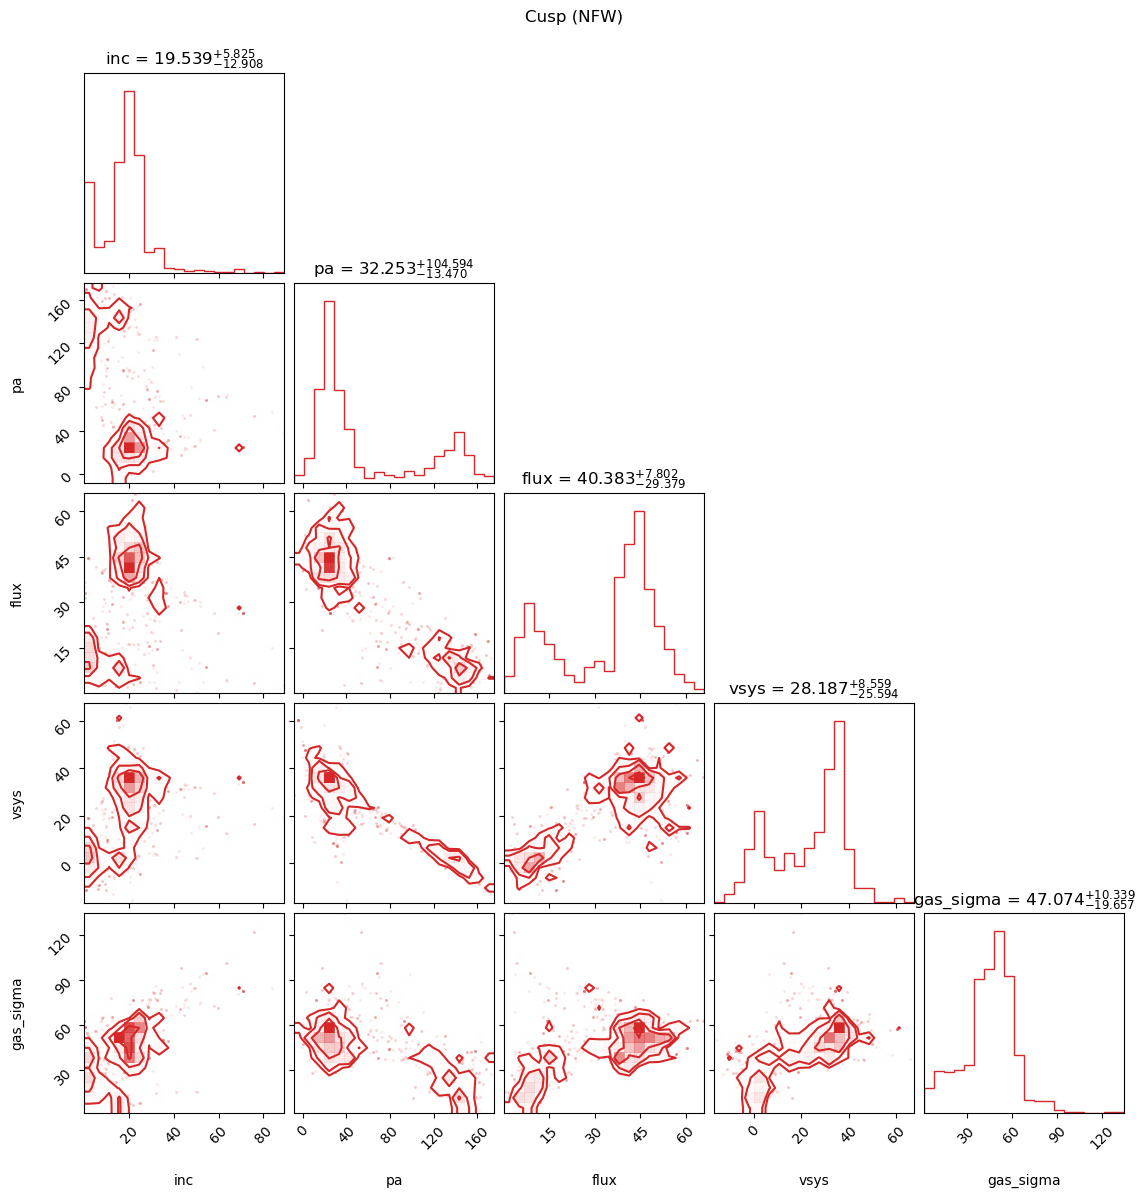

In [12]:
param_names = list(result_core.params.keys())

samples_core = result_core.chains.reshape(-1, result_core.chains.shape[-1])
samples_cusp = result_cusp.chains.reshape(-1, result_cusp.chains.shape[-1])

if HAS_CORNER:
    fig_core = corner.corner(
        samples_core, labels=param_names, show_titles=True,
        title_fmt=".3f", color="C0",
    )
    fig_core.suptitle("Core (pseudo-isothermal)", y=1.02)
    plt.show()

    fig_cusp = corner.corner(
        samples_cusp, labels=param_names, show_titles=True,
        title_fmt=".3f", color="C3",
    )
    fig_cusp.suptitle("Cusp (NFW)", y=1.02)
    plt.show()
else:
    for label, samples, color in [
        ("Core", samples_core, "C0"),
        ("Cusp", samples_cusp, "C3"),
    ]:
        fig, axes = plt.subplots(1, len(param_names), figsize=(14, 3))
        for i, name in enumerate(param_names):
            axes[i].hist(samples[:, i], bins=40, density=True,
                         color=color, alpha=0.7, edgecolor="none")
            axes[i].set_xlabel(name)
        fig.suptitle(f"{label} posterior marginals")
        plt.tight_layout()
        plt.show()

### Best-fit model cubes (pymakeplots)

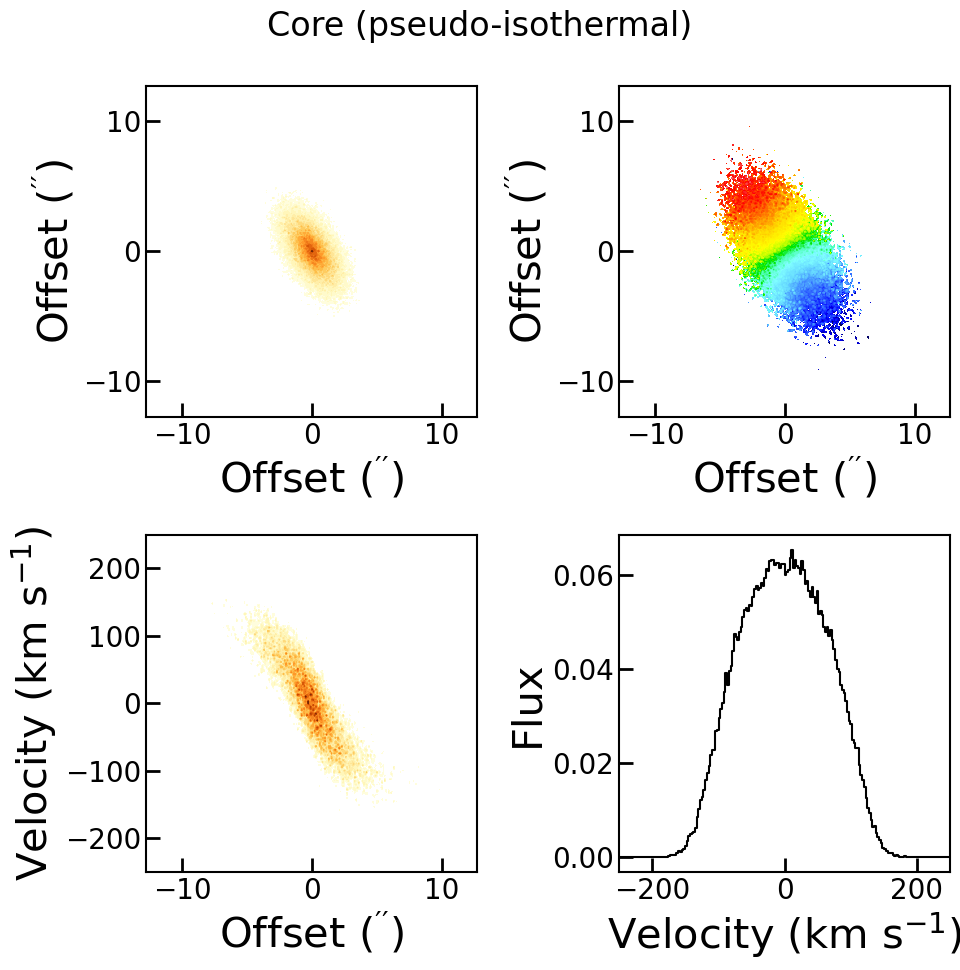

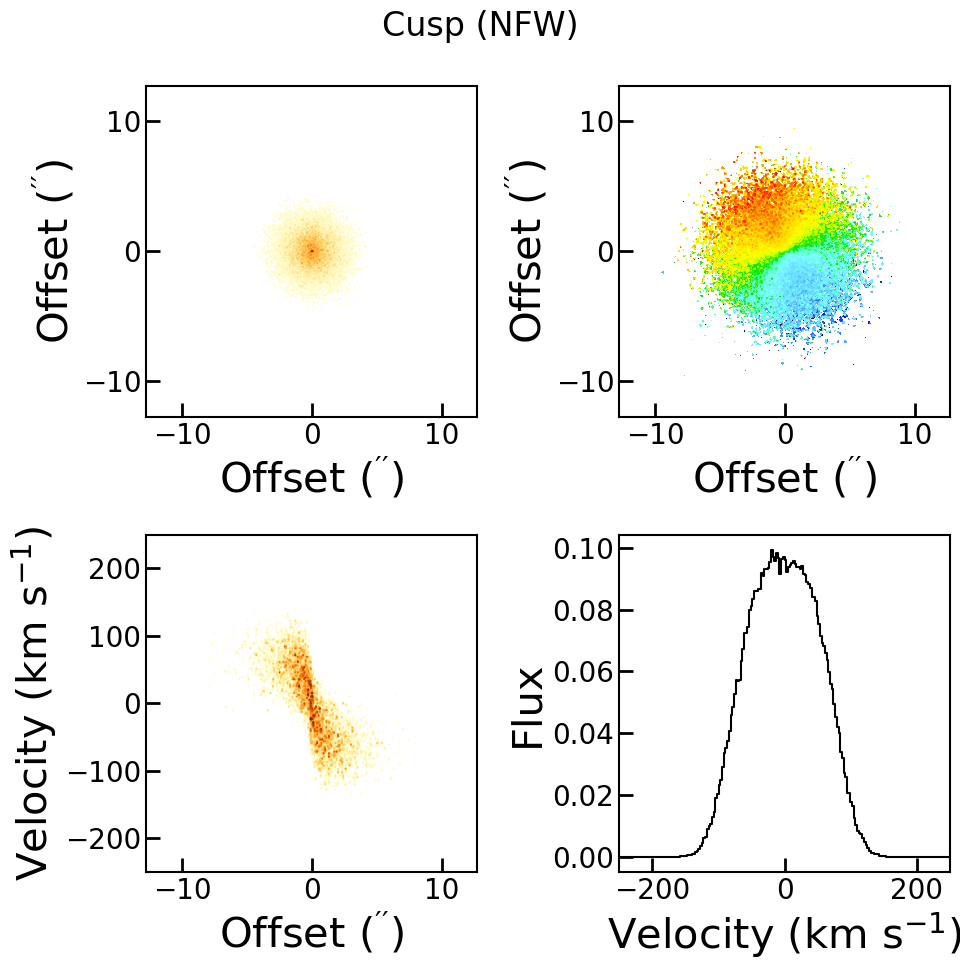

In [13]:
def model_cube_to_fits(cube_vyx, vel_kms, cellsize_arcsec, filepath):
    """Write a (v,y,x) numpy model cube to a minimal FITS for pymakeplots."""
    nv, ny, nx = cube_vyx.shape
    dv = float(np.median(np.diff(vel_kms)))
    hdr = pyfits.Header()
    hdr['CTYPE1'] = 'RA---SIN'
    hdr['CTYPE2'] = 'DEC--SIN'
    hdr['CTYPE3'] = 'VRAD'
    hdr['CDELT1'] = -cellsize_arcsec / 3600.0
    hdr['CDELT2'] = cellsize_arcsec / 3600.0
    hdr['CDELT3'] = dv * 1000.0
    hdr['CRPIX1'] = nx / 2.0 + 0.5
    hdr['CRPIX2'] = ny / 2.0 + 0.5
    hdr['CRPIX3'] = 1.0
    hdr['CRVAL1'] = 180.0
    hdr['CRVAL2'] = 45.0
    hdr['CRVAL3'] = float(vel_kms[0]) * 1000.0
    hdr['CUNIT1'] = 'deg'
    hdr['CUNIT2'] = 'deg'
    hdr['CUNIT3'] = 'm/s'
    hdr['BMAJ'] = cellsize_arcsec / 3600.0
    hdr['BMIN'] = cellsize_arcsec / 3600.0
    hdr['BPA'] = 0.0
    hdr['BUNIT'] = 'Jy/beam'
    hdr['RESTFRQ'] = 115271201800.0
    pyfits.writeto(filepath, cube_vyx.astype(np.float32), hdr, overwrite=True)


for label, model, result in [
    ("Core (pseudo-isothermal)", core_model, result_core),
    ("Cusp (NFW)", cusp_model, result_cusp),
]:
    cube_vyx = model.generate_cube(result.params)

    tmpfile = tempfile.NamedTemporaryFile(suffix='.fits', delete=False)
    model_cube_to_fits(cube_vyx, vel_trim, CELLSIZE, tmpfile.name)
    tmpfile.close()
    try:
        p = pmp(cube=tmpfile.name)
        p.vsys = VSYS
        p.posang = result.params["pa"]
        p.galname = label
        p.make_all()
    finally:
        os.unlink(tmpfile.name)